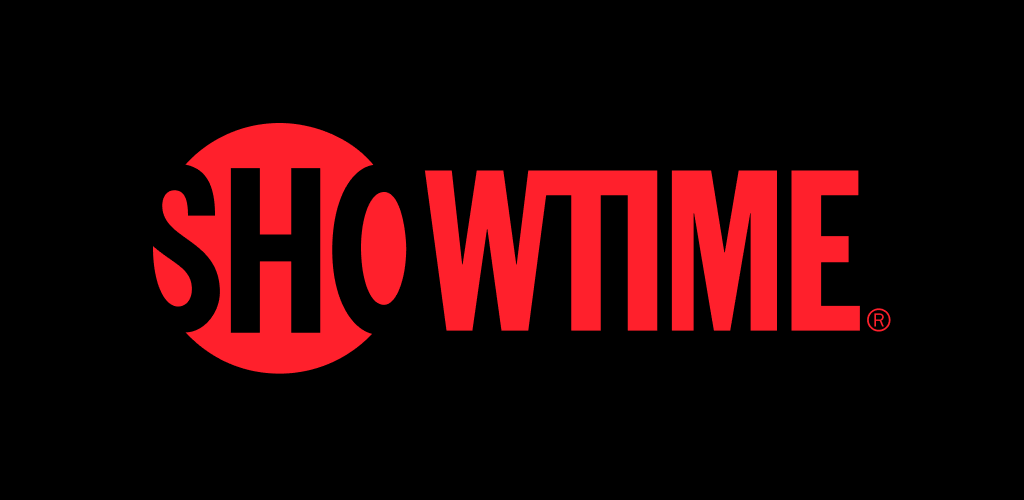

# **ShowTime**

## **Context:**
An over-the-top (OTT) media service is a media service offered directly to viewers via the internet. The term is most synonymous with subscription-based video-on-demand services that offer access to film and television content, including existing series acquired from other producers, as well as original content produced specifically for the service. They are typically accessed via websites on personal computers, apps on smartphones and tablets, or televisions with integrated Smart TV platforms.

Presently, OTT services are at a relatively nascent stage and are widely accepted as a trending technology across the globe. With the increasing change in customers' social behavior, which is shifting from traditional subscriptions to broadcasting services and OTT on-demand video and music subscriptions every year, OTT streaming is expected to grow at a very fast pace. The global OTT market size was valued at $121.61 billion in 2019 and is projected to reach $1,039.03 billion by 2027, growing at a CAGR of 29.4% from 2020 to 2027. The shift from television to OTT services for entertainment is driven by benefits such as on-demand services, ease of access, and access to better networks and digital connectivity.

With the outbreak of COVID-19, OTT services are striving to meet the growing entertainment appetite of viewers, with some platforms already experiencing a 46% increase in consumption and subscriber count as viewers seek fresh content. With innovations and advanced transformations, which will enable the customers to access everything they want in a single space, OTT platforms across the world are expected to increasingly attract subscribers on a concurrent basis.

## **Objective:**
ShowTime is an OTT service provider and offers a wide variety of content (movies, web shows, etc.) for its users. They want to determine the driver variables for first-day content viewership so that they can take necessary measures to improve the viewership of the content on their platform. Some of the reasons for the decline in viewership of content would be the decline in the number of people coming to the platform, decreased marketing spend, content timing clashes, weekends and holidays, etc. They have hired you as a Data Scientist, shared the data of the current content on their platform, and asked you to analyze the data and come up with a linear regression model to determine the driving factors for first-day viewership.



## **Data Description:**
The data contains the different factors to analyze for the content. The detailed data dictionary is given below.

**Data Dictionary:**

visitors: Average number of visitors, in millions, to the platform in the past week

ad_impressions: Number of ad impressions, in millions, across all ad campaigns for the content (running and completed)

major_sports_event: Any major sports event on the day

genre: Genre of the content

dayofweek: Day of the release of the content

season: Season of the release of the content

views_trailer: Number of views, in millions, of the content trailer

views_content: Number of first-day views, in millions, of the content

## [**Importing the necessary libraries**](https://)

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model using statsmodels
import statsmodels.api as sm

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

## [**Loading the Dataset**](https://)

### **Loading the dataset**

In [ ]:
df = pd.read_csv('/content/sample_data/ottdata.csv')


## [**Data Overview**](https://)

### **Displaying the first few rows of the dataset**

In [ ]:
df.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


### **Checking the shape of the dataset**

In [ ]:
df.shape

(1000, 8)

The number of rows and columns present the given dataset

1. The number of rows is 1000
2. The number of columns is 8

### **Checking the data types of the columns for the dataset**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


observations:

1. The visitors, ad_impressions, views_trailer and views_content belongs to float type.
2. The major_sports_event belongs to int type.
3. The genre, dayofweek and season belongs to object type.
4. There are no missing values in the dataset

### **Getting the statistical summary for the dataset**

In [ ]:
df.describe(include='all').T
# setting include='all' will get the statistical summary for both the numerical and categorical variables.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
visitors,1000.0,NaN,NaN,NaN,1.70429,0.231973,1.25,1.55,1.7,1.83,2.34
ad_impressions,1000.0,NaN,NaN,NaN,1434.71229,289.534834,1010.87,1210.33,1383.58,1623.67,2424.2
major_sports_event,1000.0,NaN,NaN,NaN,0.4,0.490143,0.0,0.0,0.0,1.0,1.0
genre,1000,8,Others,255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dayofweek,1000,7,Friday,369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,1000,4,Winter,257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views_trailer,1000.0,NaN,NaN,NaN,66.91559,35.00108,30.08,50.9475,53.96,57.755,199.92
views_content,1000.0,NaN,NaN,NaN,0.4734,0.105914,0.22,0.4,0.45,0.52,0.89


Observations:

1. In the genre column the number of unique values is 8 and the most repeated value is Others(255).
2. In the dayofweek column the number of unique values are 7 and the most repeated value is Friday(369).
3. In the season column the number of unique values are 4 and the most repeated value is Winter(257).


### **Checking for duplicate values**



In [ ]:
df.duplicated().sum()

np.int64(0)

* There are no duplicate values in the data

### **Checking for missing values**

In [ ]:
df.isnull().sum()

,0
visitors,0
ad_impressions,0
major_sports_event,0
genre,0
dayofweek,0
season,0
views_trailer,0
views_content,0


* There are no missing values in the data

## [**Exploratory Data Analysis**](https://)

### **Univariate analysis**

#### **Understanding the distribution of visitors**

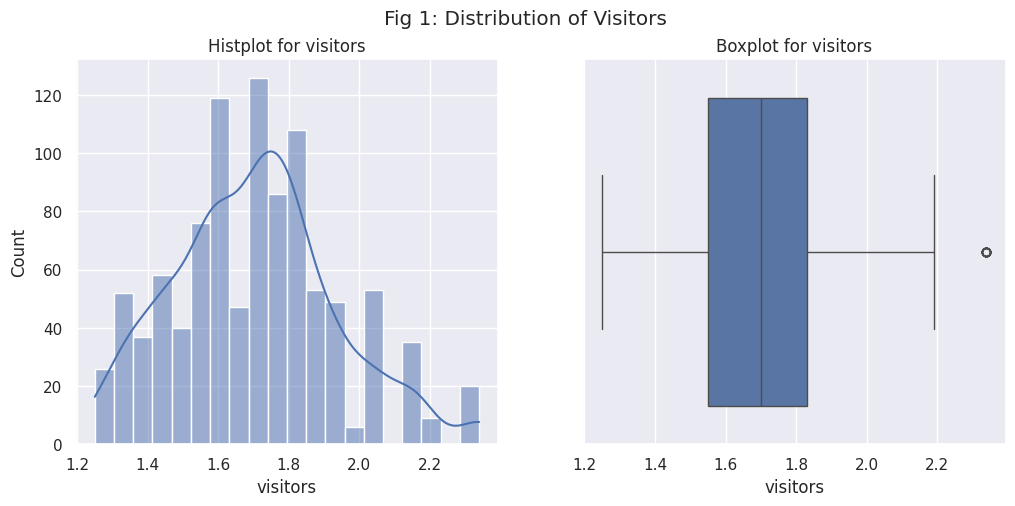

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.histplot(df, x = 'visitors', kde = True,  ax = ax[0])
sns.boxplot(df, x = 'visitors', ax = ax[1])
ax[0].set(xlabel = 'visitors')
ax[1].set(xlabel = 'visitors')
ax[0].set_title('Histplot for visitors')
ax[1].set_title('Boxplot for visitors')
fig.suptitle('Fig 1: Distribution of Visitors')
plt.show()

**Observations:**

1. Almost a normal distribution with only a single outlier can be observed.
2. Mean and median follows almost similarly at 1.7 million visitors.
.

#### **Understanding the distribution of ad_impressions**

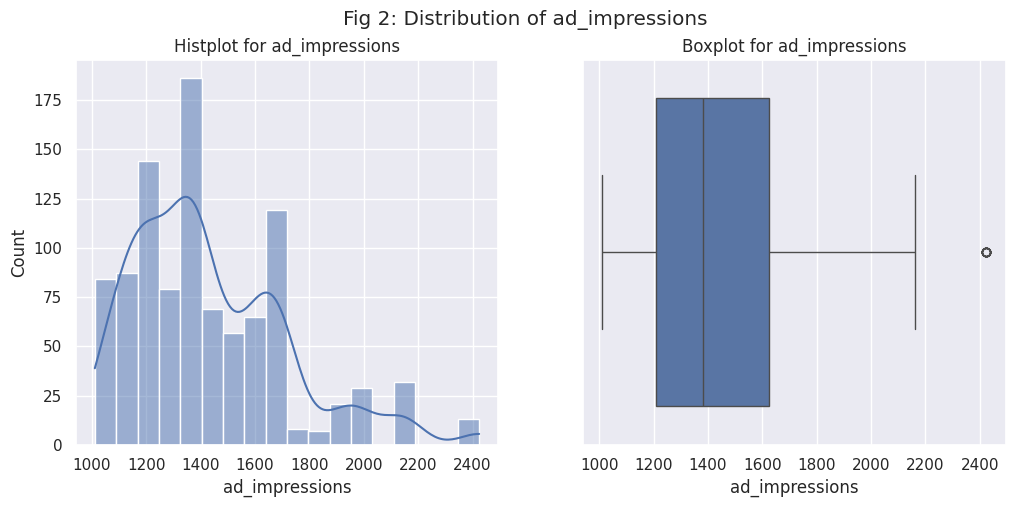

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.histplot(df, x = 'ad_impressions', kde = True,  ax = ax[0])
sns.boxplot(df, x = 'ad_impressions', ax = ax[1])
ax[0].set(xlabel = 'ad_impressions')
ax[1].set(xlabel = 'ad_impressions')
ax[0].set_title('Histplot for ad_impressions')
ax[1].set_title('Boxplot for ad_impressions')
fig.suptitle('Fig 2: Distribution of ad_impressions')
plt.show()

Observation:

1. Distribution seems to be right skewed and it's not following a normal distribution.
2. Mean ad impression is less than 1400

#### **Understanding the distribution of views_trailer**

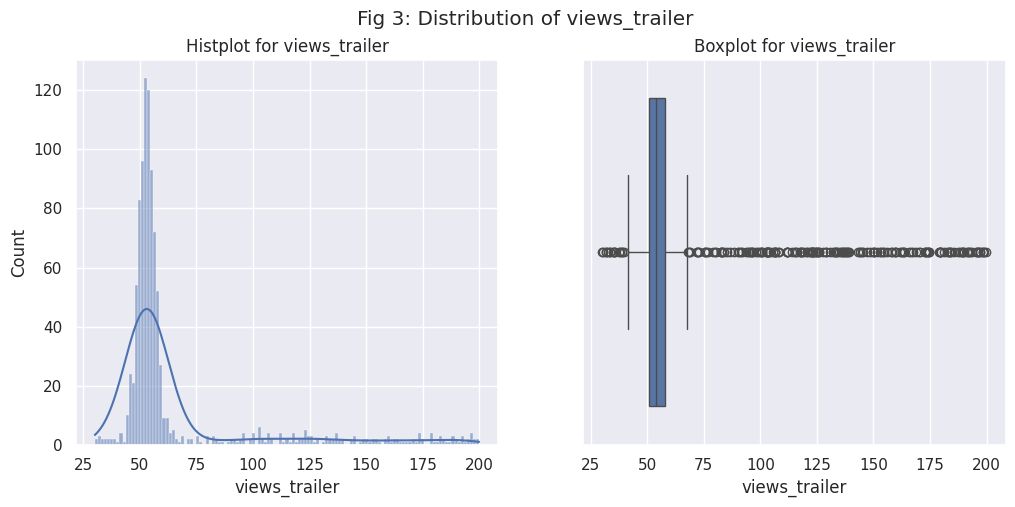

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.histplot(df, x = 'views_trailer', kde = True,  ax = ax[0])
sns.boxplot(df, x = 'views_trailer', ax = ax[1])
ax[0].set(xlabel = 'views_trailer')
ax[1].set(xlabel = 'views_trailer')
ax[0].set_title('Histplot for views_trailer')
ax[1].set_title('Boxplot for views_trailer')
fig.suptitle('Fig 3: Distribution of views_trailer')
plt.show()

**Observation**:

1. Too many outliers can be observed at both sides.
2. Heavily right-skewed data.
3. The Mean is less than 70 million viewed the trailer.

#### **Understanding the distribution of views_content**

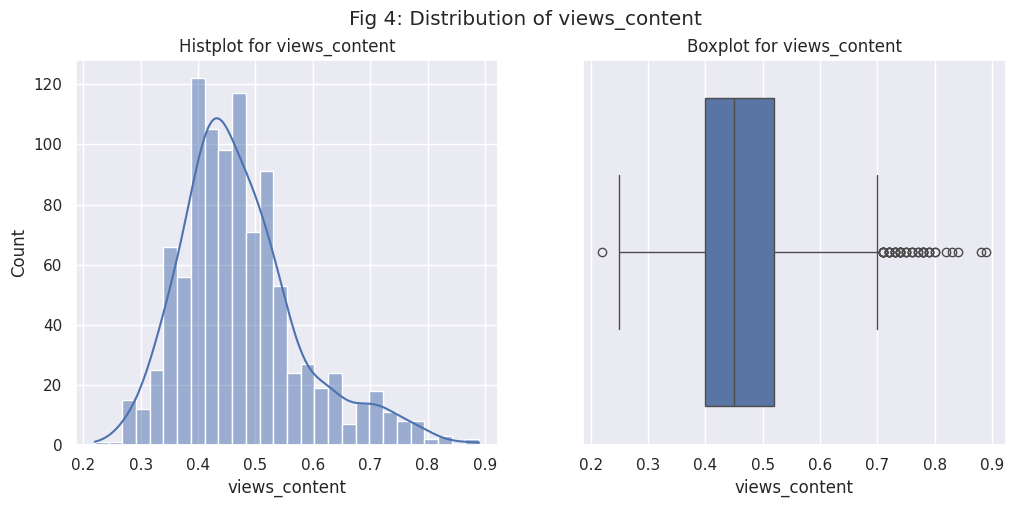

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.histplot(df, x = 'views_content', kde = True,  ax = ax[0])
sns.boxplot(df, x = 'views_content', ax = ax[1])
ax[0].set(xlabel = 'views_content')
ax[1].set(xlabel = 'views_content')
ax[0].set_title('Histplot for views_content')
ax[1].set_title('Boxplot for views_content')
fig.suptitle('Fig 4: Distribution of views_content')
plt.show()

**Observation:**

1. Less than 0.5 million watched the actual content.
2. Many outliers can be observed.
3. Distribution is right skewed. However, it seems like a normal distribution.

#### **Understanding the distribution of genre**

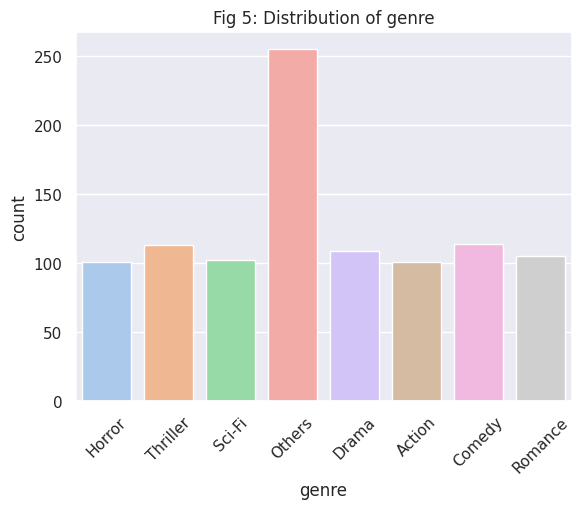

In [ ]:
sns.countplot(df, x = 'genre', hue = 'genre', palette = 'pastel')
plt.xticks(rotation = 45)
plt.title('Fig 5: Distribution of genre')
plt.show()

**Observation:**

* Genre “others” has the maximum counts in the data followed by Comedy & Thriller.

#### **Understanding the distribution of dayofweek**

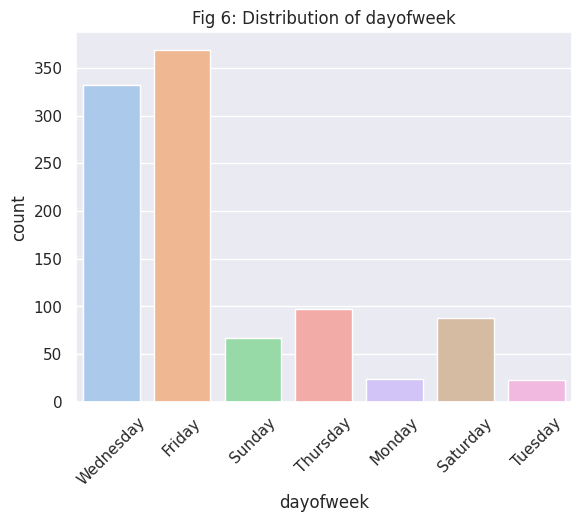

In [ ]:
sns.countplot(df, x = 'dayofweek', hue = 'dayofweek', palette = 'pastel')
plt.xticks(rotation = 45)
plt.title('Fig 6: Distribution of dayofweek')
plt.show()

**Observation:**

1. Mostly content released on Friday followed by Wednesday.
2. Very less content released on Monday.

#### **Understanding the distribution of season**

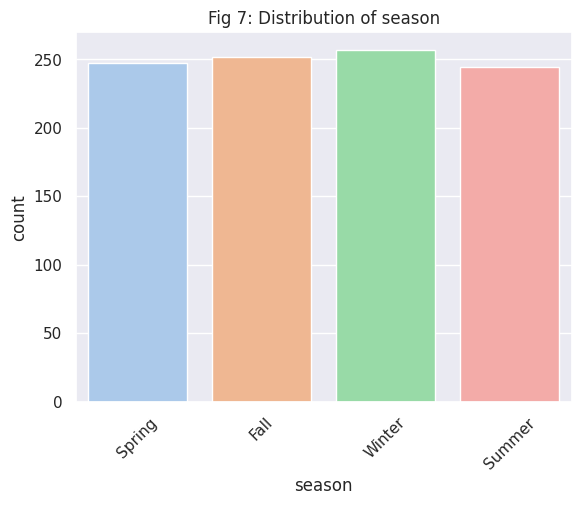

In [ ]:
sns.countplot(df, x = 'season', hue = 'season', palette = 'pastel')
plt.xticks(rotation = 45)
plt.title('Fig 7: Distribution of season')
plt.show()

**Observation:**

1. There are four seasons in the data.
2. Mostly content released in Winter.
3. The remaining seasons have almost equal values.


#### **Understanding the distribution of major_sports_event**

Text(0.5, 1.0, 'Fig 8: Distribution of major_sports_event')

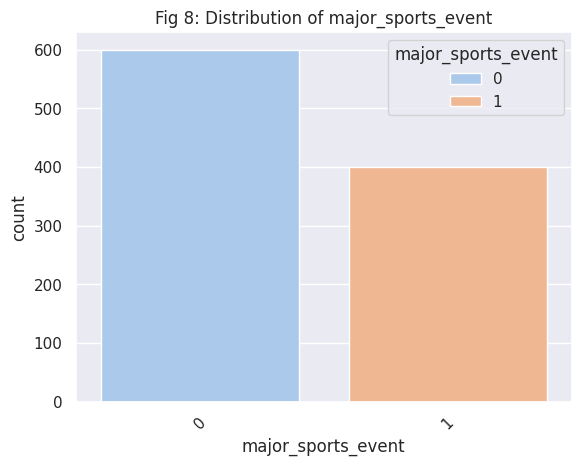

In [ ]:
sns.countplot(df, x = 'major_sports_event', hue = 'major_sports_event', palette = 'pastel')
plt.xticks(rotation = 45)
plt.title('Fig 8: Distribution of major_sports_event')

**observation:**

1. Mostly the content released when there is no major sport event happening.

### **Bivariate analysis**

#### **Correlation between all numerical variables**

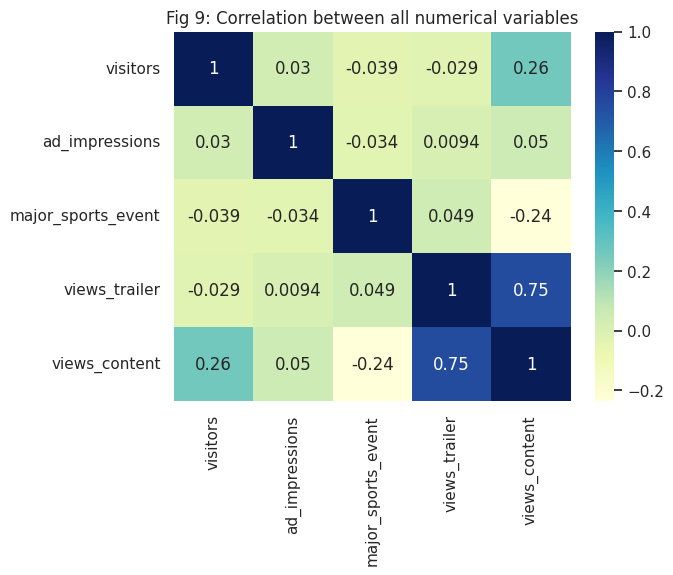

In [ ]:
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'YlGnBu')
plt.title('Fig 9: Correlation between all numerical variables')
plt.xticks(rotation = 90)
plt.show()

**Observation:**

1. Positive correlation can be observed between views content and views trailer.
2. Positive effect of visitor towards the content view can be observed.
3. A negative correlation can be observed between major sports event and content views

#### **Visualising the relationship between Genre and Content_views**

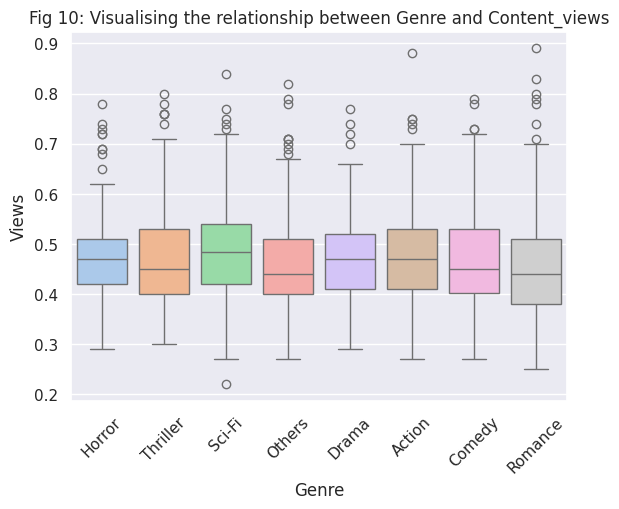

In [ ]:
sns.boxplot(data = df, x = 'genre', y = 'views_content',hue = 'genre', palette = 'pastel')
plt.xlabel('Genre')
plt.ylabel('Views')
plt.title('Fig 10: Visualising the relationship between Genre and Content_views')
plt.xticks(rotation = 45)
plt.show()

**Observation:**

1. Sci-Fi and comedy genres have slightly higher median views compared to others.
2. All genres show a similar range of views(0.3 to 0.7), but there are many outliers, especially above 0.7.

#### **Visualising the relationship between season and visitors**

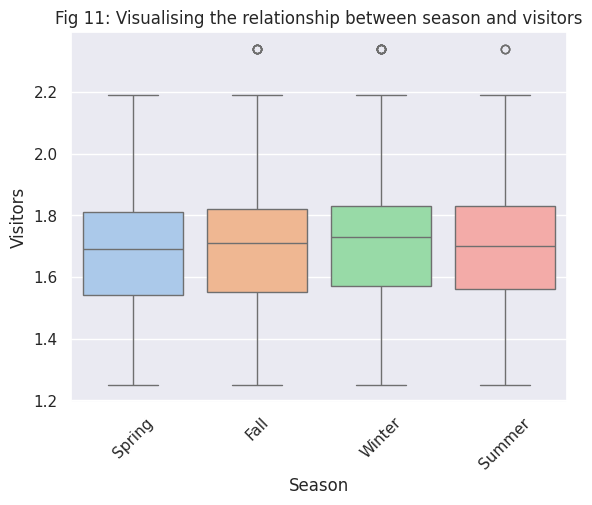

In [ ]:
sns.boxplot(data = df, x = 'season', y = 'visitors',hue = 'season' , palette = 'pastel')
plt.xlabel('Season')
plt.ylabel('Visitors')
plt.title('Fig 11: Visualising the relationship between season and visitors')
plt.xticks(rotation = 45)
plt.show()

**Observation:**

1.There are four seasons and all seasons there is not much difference.

#### **Visualising the relationship between Season and views_content**

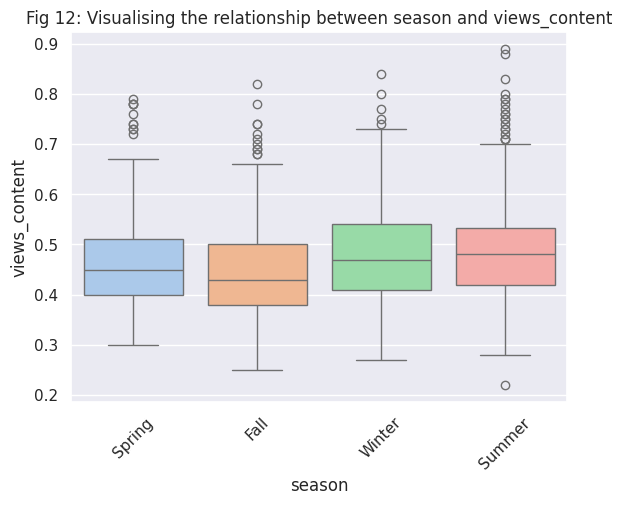

In [ ]:
sns.boxplot(data = df, x = 'season', y = 'views_content',hue = 'season' ,palette = 'pastel')
plt.title('Fig 12: Visualising the relationship between season and views_content')
plt.xticks(rotation = 45)
plt.show()

**Observation:**

1. There are outliers present for all the season.
2. Average content views for all the seasons looks in between 0.43 to 0.5 million.
3. In the winter and summer mean content views increases than the fall and spring season.

#### **Visualising the relationship between Dayofweeks and views_content**

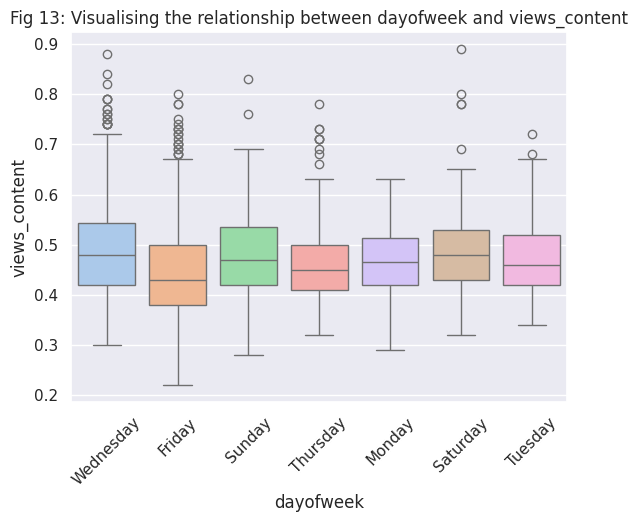

In [ ]:
sns.boxplot(data = df, x = 'dayofweek', y = 'views_content', palette = 'pastel', hue = 'dayofweek')
plt.title('Fig 13: Visualising the relationship between dayofweek and views_content')
plt.xticks(rotation = 45)
plt.show()

**Observation:**

1. There are outliers present for almost all the days of week.
2. Wednesday and Saturday have higher mean values than the other week days.


#### **Visualising the relationship between Genre and views_content**

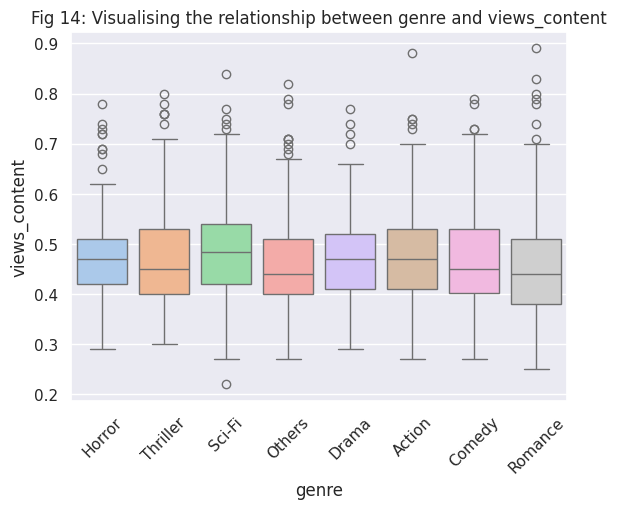

In [ ]:
sns.boxplot(data = df, x = 'genre', y = 'views_content',hue = 'genre', palette = 'pastel')
plt.title('Fig 14: Visualising the relationship between genre and views_content')
plt.xticks(rotation = 45)
plt.show()

**Observation:**

1. There are outliers present for almost all the Genres.
2. Mean value lies between 4 to 5 approximately.

#### **Visualising the relationship between visitor and views_content**

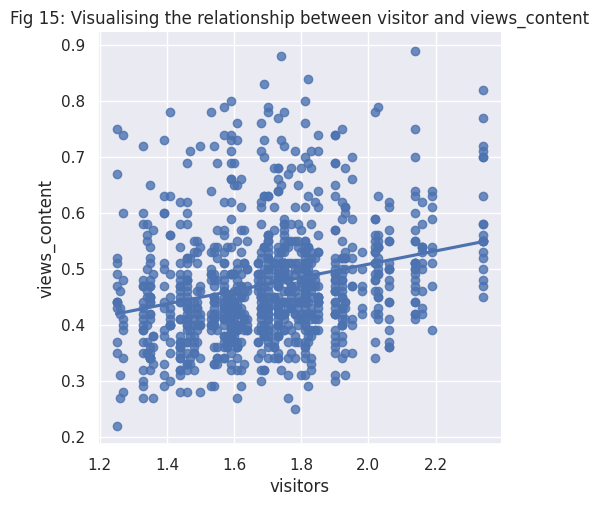

In [ ]:
sns.lmplot(data = df, x = 'visitors', y = 'views_content', ci = True)
plt.title('Fig 15: Visualising the relationship between visitor and views_content')
plt.show()

**Observation:**

1. There is a positive correlation between views_content and the visitors
2. Although no clear pattern, still positive correlation is observed.

#### **Visualising the relationship between views_content and views_trailer**

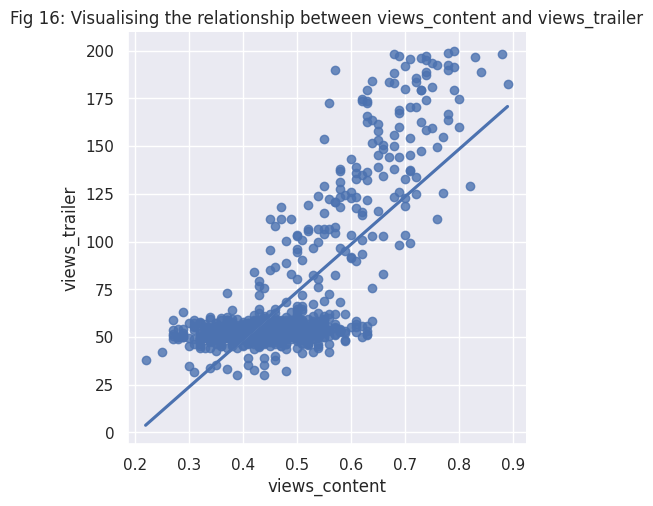

In [ ]:
sns.lmplot(data = df, x = 'views_content', y = 'views_trailer', ci = True)
plt.title('Fig 16: Visualising the relationship between views_content and views_trailer')
plt.show()

**Observation:**

1. The views_content and views_trailer have positive correlation.


### **Key Questions**

#### **1. What does the distribution of content views look like?**

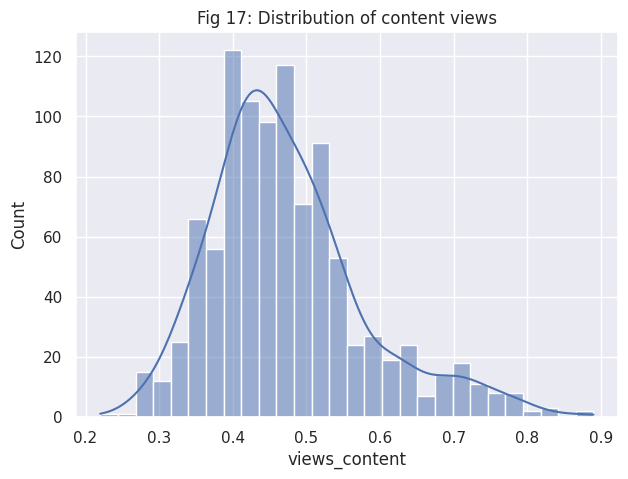

In [ ]:
plt.figure(figsize = (7,5))
sns.histplot(df['views_content'], kde = True)
plt.title('Fig 17: Distribution of content views')
plt.show()

**Observation:**

1. Little right skewed but looks normally distributed data.
2. Mean value between 4 to 5

#### **2. What does the distribution of genres look like?**


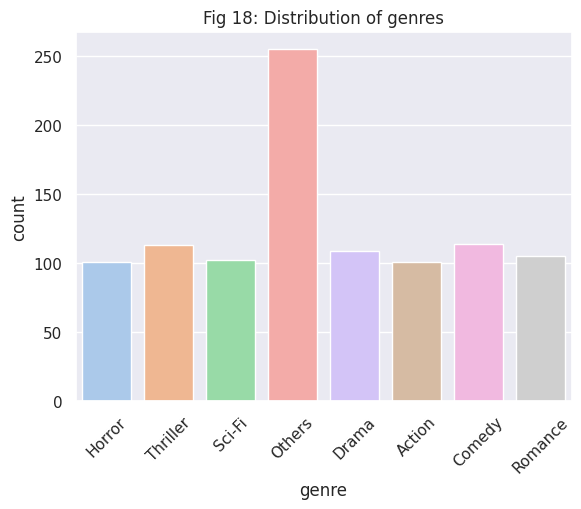

In [ ]:
sns.countplot(df, x = 'genre', hue = 'genre', palette = 'pastel')
plt.title('Fig 18: Distribution of genres')
plt.xticks(rotation = 45)
plt.show()

**Observations:**

* The count plot reveals that Others is the most popular genre, followed by Comedy and Thriller.

#### **3. The day of the week on which content is released generally plays a key role in the viewership. How does the viewership vary with the day of release?**

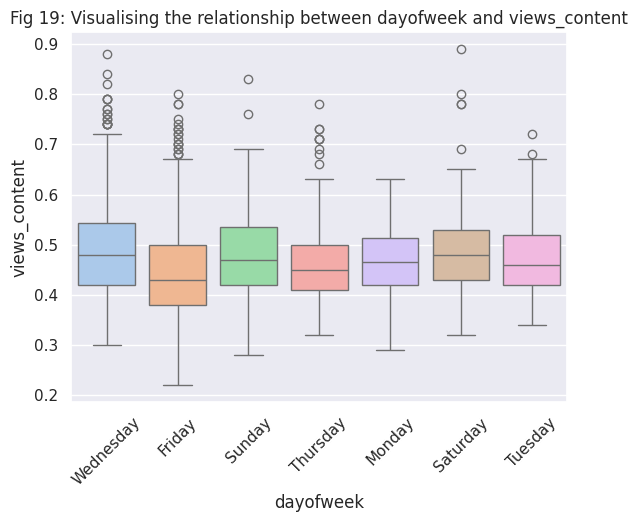

In [ ]:
sns.boxplot(data = df, x = 'dayofweek', y = 'views_content', palette = 'pastel', hue = 'dayofweek')
plt.title('Fig 19: Visualising the relationship between dayofweek and views_content')
plt.xticks(rotation = 45)
plt.show()

**Observation:**
1. There are outliers present for almost all the days of week.
2. Wednesday and Saturday have higher mean values than the other week days.


#### **4. How does the viewership vary with the season of release?**


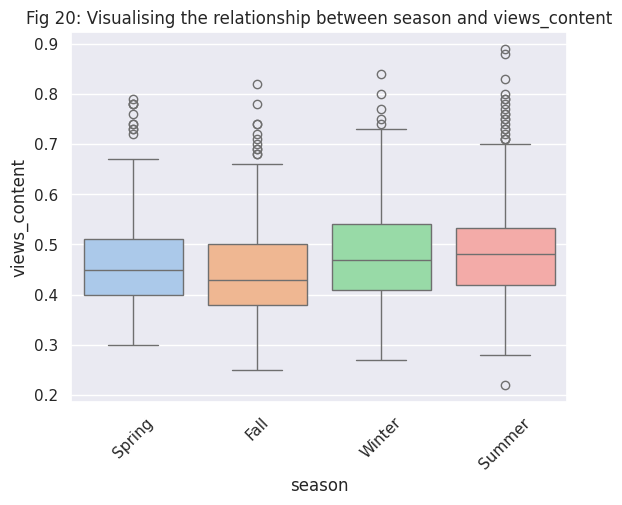

In [ ]:
sns.boxplot(data = df, x = 'season', y = 'views_content', palette = 'pastel', hue = 'season')
plt.title('Fig 20: Visualising the relationship between season and views_content')
plt.xticks(rotation = 45)
plt.show()

**Observation:**

1. There are outliers present for all the season.
2. Average content views for all the seasons looks in between 0.43 to 0.5 million.
3. In the winter and summer mean content views increase than the fall and spring season.

#### **5. What is the correlation between trailer views and content views?**


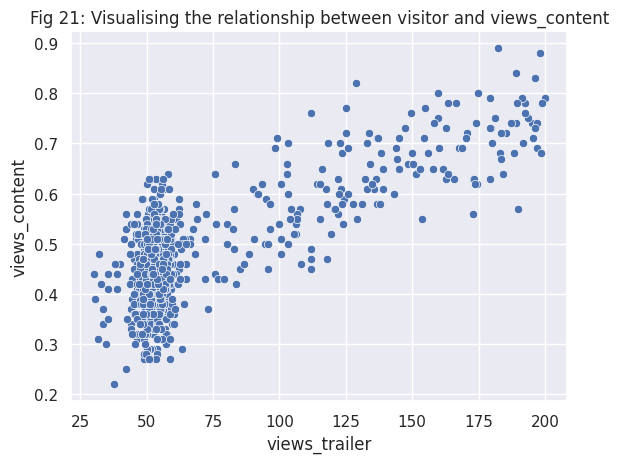

In [ ]:
sns.scatterplot(data = df, x = 'views_trailer', y = 'views_content')
plt.title('Fig 21: Visualising the relationship between visitor and views_content')
plt.show()

**Observations:**

1. When trailer views increase, content views also increase.
2. More data points are crowded between 40 to 70 trailer views.
3. High trailer views (above 100) lead to high and stable content views.

## [**Data Pre-Processing**](https://)

Data Preprocessing includes the data for modelling by:

1. **Checking for duplicates.**

2. **Checking for missing values.**

3. **Detecting outliers in content views.**

4. **Feature engineering.**

5. **Data preparation for modeling.**

#### **1. Checking for duplicates.**

In [ ]:
df.duplicated().value_counts()

,count
False,1000


**Observation:**

No Duplicates are found in the given dataset.

#### **2. Checking for missing values.**

In [ ]:
df.isnull().sum()

,0
visitors,0
ad_impressions,0
major_sports_event,0
genre,0
dayofweek,0
season,0
views_trailer,0
views_content,0


Observation:

No Missing values are found in the given dataset.

#### **3. Detecting outliers in content views.**


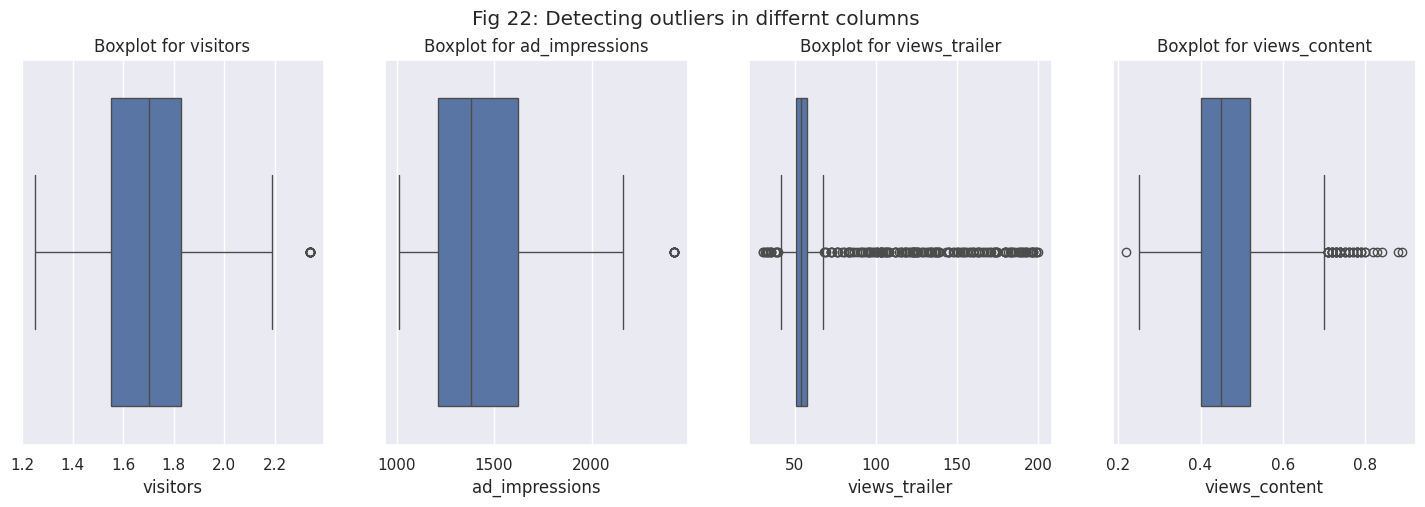

In [ ]:
fig, ax = plt.subplots(1,4, figsize=(18,5))
sns.boxplot(df, x = 'visitors', ax = ax[0])
sns.boxplot(df, x = 'ad_impressions', ax = ax[1])
sns.boxplot(df, x = 'views_trailer', ax = ax[2])
sns.boxplot(df, x = 'views_content', ax = ax[3])
ax[0].set(xlabel = 'visitors')
ax[1].set(xlabel = 'ad_impressions')
ax[2].set(xlabel = 'views_trailer')
ax[3].set(xlabel = 'views_content')
ax[0].set_title('Boxplot for visitors')
ax[1].set_title('Boxplot for ad_impressions')
ax[2].set_title('Boxplot for views_trailer')
ax[3].set_title('Boxplot for views_content')
fig.suptitle('Fig 22: Detecting outliers in differnt columns')
plt.show()

**Observations:**

* There are outliers especially higher in views trailer & views_content but after data analysis we can say they are valid observations.

* So, we will not treat outliers and leave as it is in the dataset and process further and they are Meaningful Outliers.

* These outliers represent valid scenarios because OTT platform, certain movies orshows might genuinely have significantly higher trailer views or content views due to their popularity, star cast, marketing, etc. so, we cannot remove/treat them.

* Outliers represent valid scenarios, for example, a blockbuster movie’s high trailers and views; they should not be removed or treated. These outliers are informative and provide insights into what drives high viewership.

#### **4. Feature engineering.**

For the column major_sports_event, replace the 1 values with 'yes' and 0 values with 'no'.

In [ ]:
df["major_sports_event"] = df["major_sports_event"].replace({1: "yes", 0: "no"})
df.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,no,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,yes,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,yes,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,yes,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,no,Sci-Fi,Sunday,Winter,55.83,0.46


#### **5. Data preparation for modeling.**





* Before we proceed to build a model, we'll have to encode categorical features
* We'll split the data into train and test to be able to evaluate the model that we build on the train data
* We will build a Linear Regression model using the train data and then check it's performance

In [ ]:
# splitting the data into the dependent and independent variables
X = df.drop("views_content", axis=1)
y = df["views_content"]

print(X.head())
print(y.head())

   visitors  ad_impressions major_sports_event     genre  dayofweek  season  \
0      1.67         1113.81                 no    Horror  Wednesday  Spring   
1      1.46         1498.41                yes  Thriller     Friday    Fall   
2      1.47         1079.19                yes  Thriller  Wednesday    Fall   
3      1.85         1342.77                yes    Sci-Fi     Friday    Fall   
4      1.46         1498.41                 no    Sci-Fi     Sunday  Winter   

   views_trailer  
0          56.70  
1          52.69  
2          48.74  
3          49.81  
4          55.83  
0    0.51
1    0.32
2    0.39
3    0.44
4    0.46
Name: views_content, dtype: float64


In [ ]:
# creating dummy variables
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True,
)

X.head()

,visitors,ad_impressions,views_trailer,major_sports_event_yes,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,genre_Sci-Fi,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.67,1113.81,56.70,False,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False
1,1.46,1498.41,52.69,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,1.47,1079.19,48.74,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
3,1.85,1342.77,49.81,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,1.46,1498.41,55.83,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True


In [ ]:
# this adds the constant term to the dataset
X = sm.add_constant(X)

In [ ]:
# converting the input attributes into float type for modeling
X = X.astype(float)
X.head()

,const,visitors,ad_impressions,views_trailer,major_sports_event_yes,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,...,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.0,1.67,1113.81,56.70,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.0,1.46,1498.41,52.69,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.47,1079.19,48.74,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,1.85,1342.77,49.81,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.46,1498.41,55.83,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# splitting the data in 70:30 ratio for train to test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1
)

In [ ]:
print('Training set shape', X_train.shape, y_train.shape[0])
print('Testing set shape', X_test.shape, y_test.shape[0])

Training set shape (700, 21) 700
Testing set shape (300, 21) 300


## [**Model Building- Linear Regression**](https://)

### **Make the linear model using statsmodels OLS and print the model summary.**

In [ ]:
X_train = X_train.astype('float')
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     129.0
Date:                Wed, 09 Jul 2025   Prob (F-statistic):          1.32e-215
Time:                        05:31:35   Log-Likelihood:                 1124.6
No. Observations:                 700   AIC:                            -2207.
Df Residuals:                     679   BIC:                            -2112.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

### **Interpreting the Regression Results:**

1. **Adjusted. R-squared:** It reflects the fit of the model.
  * Adjusted R-squared values generally range from 0 to 1, where a higher value generally indicates a better fit, assuming certain conditions are met.
  * In our case, the value for adj. R-squared is **0.785**, which is good.
2. **const coefficient:** It is the Y-intercept.
  * It means that if all the predictor variable coefficients are zero, then the expected output (i.e., Y) would be equal to the const coefficient.
  * In our case, the value for const coefficient is **0.0602**.
3. **Coefficient of a predictor variable:** It represents the change in the output Y due to a change in the predictor variable (everything else held constant).
  * In our case, the coefficient of duration is **0.1295**.

### **Display model coefficients with column names**

In [ ]:
# Coefficients with names
coeff_df = model.params.reset_index()
coeff_df.columns = ['Column_Names', 'Coefficient']
print(coeff_df)

              Column_Names  Coefficient
0                    const     0.060157
1                 visitors     0.129451
2           ad_impressions     0.000004
3            views_trailer     0.002330
4   major_sports_event_yes    -0.060326
5             genre_Comedy     0.009352
6              genre_Drama     0.012625
7             genre_Horror     0.009862
8             genre_Others     0.006325
9            genre_Romance     0.000551
10            genre_Sci-Fi     0.013143
11          genre_Thriller     0.008708
12        dayofweek_Monday     0.033662
13      dayofweek_Saturday     0.057887
14        dayofweek_Sunday     0.036321
15      dayofweek_Thursday     0.017289
16       dayofweek_Tuesday     0.022837
17     dayofweek_Wednesday     0.047376
18           season_Spring     0.022602
19           season_Summer     0.044203
20           season_Winter     0.027161


### **Model Performance Check**

Let's check the performance of the model using different metrics.

* We will be using metric functions defined in sklearn for RMSE, MAE, and  R2 .

* We will define a function to calculate MAPE and adjusted  R2 .

* The mean absolute percentage error (MAPE) measures the accuracy of predictions as a percentage, and can be calculated as the average absolute percent error for each predicted value minus actual values divided by actual values. It works best if there are no extreme values in the data and none of the actual values are 0.
* We will create a function which will print out all the above metrics in one go.

In [ ]:
# function to compute adjusted R-squared
from sklearn.metrics import r2_score

def adj_r2_score(predictors, target, predictions):
    r2 = r2_score(target, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# function to compute MAPE
def mape_score(target, predictions):
    return np.mean(np.abs((target - predictions) / target)) * 100

## function to compute different matrics to check performance of regression model
def model_performance_regression_(model, predictors, target):
    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)                 ## to compute r2
    adj_r2 = adj_r2_score(predictors, target, pred)   ## to compute adj_r2
    mape = mape_score(target, pred)                   ## to compute mape
    rmse = np.sqrt(mean_squared_error(target, pred))  ## to compute rmse
    mae = mean_absolute_error(target, pred)           ## to compute mae

## creating the dataframe to matrix
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "MAPE": mape,
            "R2": r2,
            "Adj_R2": adj_r2

        }, index=[0]
    )
    return df_perf

#### **Testing the model performance on train and test data**

In [ ]:
# testing the model performance on train data
print('Train Performance')
print("Shape of predictors (X_train):", X_train.shape)
print("Number of model parameters:", len(model.params))
olsmodel_train_pref = model_performance_regression_(model, X_train, y_train)
olsmodel_train_pref

Train Performance
Shape of predictors (X_train): (700, 21)
Number of model parameters: 21


,RMSE,MAE,MAPE,R2,Adj_R2
0,0.04853,0.038197,8.55644,0.791616,0.785162


In [ ]:
# testing the model performance on test data
print('Test Performance')
print("Shape of predictors (X_test):", X_test.shape)
print("Number of model parameters:", len(model.params))
olsmodel_test_pref = model_performance_regression_(model, X_test, y_test)
olsmodel_test_pref

Test Performance
Shape of predictors (X_test): (300, 21)
Number of model parameters: 21


,RMSE,MAE,MAPE,R2,Adj_R2
0,0.050603,0.040782,9.030464,0.766447,0.748804


### **Observations on 1st Model:**



* The training  R2  is 0.791616, so the model is not underfitting

* The train and test RMSE and MAE are comparable, so the model is not overfitting either

* MAE suggests that the model can predict content views within a mean error of 0.04 on the test data

* MAPE of 9.03 on the test data means that we are able to predict within 9.03% of the content views.

## [**Checking Linear Regression Assumptions**](https://)

We will be checking the following Linear Regression assumptions:

**1. No Multicollinearity**

**2. Linearity of variables**

**3. Independence of error terms**

**4. Normality of error terms**

**5. No Heteroscedasticity**

### **Test For Multicollinearity**

TEST FOR MULTICOLLINEARITY

* Multicollinearity occurs when predictor variables in a regression model are correlated. This correlation is a problem because predictor variables should be independent. If the correlation between variables is high, it can cause problems when we fit the model and interpret the results. When we have multicollinearity in the linear model, the coefficients that the model suggests are unreliable.

* There are different ways of detecting (or testing) multicollinearity. One such way is by using the Variance Inflation Factor, or VIF.

* Variance Inflation Factor (VIF): Variance inflation factors measure the inflation in the variances of the regression parameter estimates due to collinearities that exist among the predictors. It is a measure of how much the variance of the estimated regression coefficient  βk  is "inflated" by the existence of correlation among the predictor variables in the model.

* If VIF is 1, then there is no correlation among the  k th predictor and the remaining predictor variables, and hence, the variance of  βk  is not inflated at all.

* General Rule of thumb:

  * If VIF is between 1 and 5, then there is low multicollinearity.

  * If VIF is between 5 and 10, we say there is moderate multicollinearity.
  * If VIF is exceeding 10, it shows signs of high multicollinearity.

##### **Let's define a function to check VIF.**

In [ ]:
# we will define a function to check VIF
def checking_vif(predictors):
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif
checking_vif(X_train)

,feature,VIF
0,const,99.679317
1,visitors,1.027837
2,ad_impressions,1.029390
3,views_trailer,1.023551
4,major_sports_event_yes,1.065689
5,genre_Comedy,1.917635
6,genre_Drama,1.926699
7,genre_Horror,1.904460
8,genre_Others,2.573779
9,genre_Romance,1.753525


**Observation on VIF values:**

1. After computing the variance inflation factor it is seen that  "genre_Others" which has VIF value more than 2.0.

2. Other variable are having the variance inflation factor less than 2.0 value.

3. We can concluding that no value is greater than 5 , stating there is no multicollinearity .



### **Dropping high p-value variables**


Dropping high p-value variables


* We will drop the predictor variables having a p-value greater than 0.05 as they do not significantly impact the target variable.

* But sometimes p-values change after dropping a variable. So, we'll not drop all variables at once.

* Instead, we will do the following:
    * Build a model, check the p-values of the variables, and drop the column with the highest p-value.
    * Create a new model without the dropped feature, check the p-values of the variables, and drop the column with the highest p-value.
    * Repeat the above two steps till there are no columns with p-value > 0.05.
    
The above process can also be done manually by picking one variable at a time that has a high p-value, dropping it, and building a model again. But that might be a little tedious and using a loop will be more efficient.

In [ ]:
# initial list of columns
cols = X_train.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    x_train_aux = X_train[cols]

    # fitting the model
    model = sm.OLS(y_train, x_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)


['const', 'visitors', 'views_trailer', 'major_sports_event_yes', 'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Sunday', 'dayofweek_Thursday', 'dayofweek_Wednesday', 'season_Spring', 'season_Summer', 'season_Winter']


In [ ]:
X_train1 = X_train[selected_features]
X_test1 = X_test[selected_features]

In [ ]:
olsmodel2 = sm.OLS(y_train, X_train1).fit()
print(olsmodel2.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     233.8
Date:                Wed, 09 Jul 2025   Prob (F-statistic):          7.03e-224
Time:                        05:35:51   Log-Likelihood:                 1120.2
No. Observations:                 700   AIC:                            -2216.
Df Residuals:                     688   BIC:                            -2162.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

#### **Testing the model performance on train and test data**

In [ ]:
# testing the model performance on train data
print('Train Performance')
print("Shape of predictors (X_train):", X_train.shape)
print("Number of model parameters:", len(model.params))
olsmodel_train_pref = model_performance_regression_(olsmodel2, X_train1, y_train)
olsmodel_train_pref

Train Performance
Shape of predictors (X_train): (700, 21)
Number of model parameters: 12


,RMSE,MAE,MAPE,R2,Adj_R2
0,0.048841,0.038385,8.595246,0.788937,0.785251


In [ ]:
# testing the model performance on test data
print('Test Performance')
print("Shape of predictors (X_test):", X_test.shape)
print("Number of model parameters:", len(model.params))
olsmodel_test_pref = model_performance_regression_(olsmodel2, X_test1, y_test)
olsmodel_test_pref

Test Performance
Shape of predictors (X_test): (300, 21)
Number of model parameters: 12


,RMSE,MAE,MAPE,R2,Adj_R2
0,0.051109,0.041299,9.177097,0.761753,0.751792


#### **Observations**


**Observations**

* Now no feature has p-value greater than 0.05, so we'll consider the features in *x_train1* as the final set of predictor variables and *olsmodel2* as the final model to move forward with
* Now adjusted R-squared is  0.786, i.e., our model is able to explain ~78% of the variance
* This shows that the variables we dropped were not affecting the model
* RMSE and MAE values are comparable for train and test sets, indicating that the model is not overfitting

### **Test for Linearity and Independence**

TEST FOR LINEARITY AND INDEPENDENCE


* We will test for linearity and independence by making a plot of fitted values vs residuals and checking for patterns.
* If there is no pattern, then we say the model is linear and residuals are independent.
* Otherwise, the model is showing signs of non-linearity and residuals are not independent.

In [ ]:
# let us create a dataframe with actual, fitted and residual values
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train  # actual values
df_pred["Fitted Values"] = olsmodel2.fittedvalues  # predicted values
df_pred["Residuals"] = olsmodel2.resid  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
731,0.40,0.445434,-0.045434
716,0.70,0.677403,0.022597
640,0.42,0.433999,-0.013999
804,0.55,0.562030,-0.012030
737,0.59,0.547786,0.042214


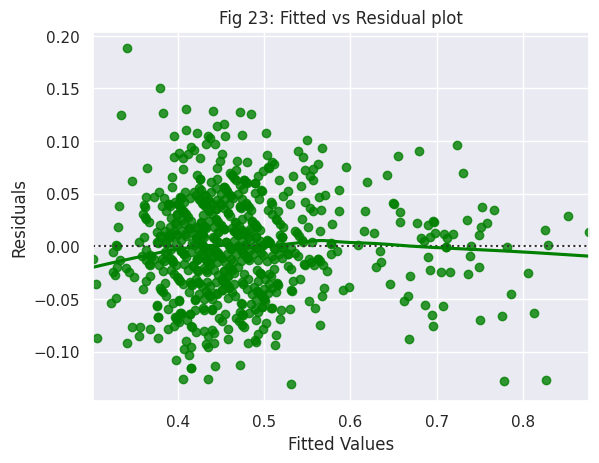

In [ ]:
# let's plot the fitted values vs residuals

sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="green", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fig 23: Fitted vs Residual plot")
plt.show()

**Observations**

1. The scatter plot shows the distribution of residuals (errors) vs fitted values (predicted values).

2. If there exist any pattern in this plot, we consider it as signs of non-linearity in the data and a pattern means that the model doesn't capture non-linear effects.

3. **We see no pattern in the plot above. Hence, the assumptions of linearity and independence are satisfied.**

### **Test for Normality**

TEST FOR NORMALITY

* We will test for normality by checking the distribution of residuals, by checking the Q-Q plot of residuals, and by using the Shapiro-Wilk test.
* If the residuals follow a normal distribution, they will make a straight line plot, otherwise not.
* If the p-value of the Shapiro-Wilk test is greater than 0.05, we can say the residuals are normally distributed.

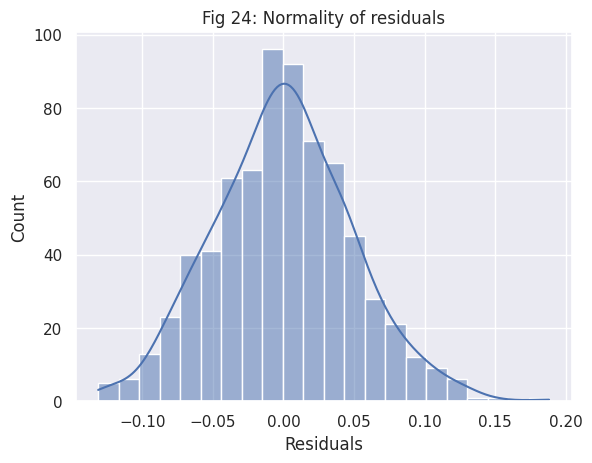

In [ ]:
sns.histplot(data=df_pred, x="Residuals", kde=True)
plt.title("Fig 24: Normality of residuals")
plt.show()

**Observations**

* The histogram of residuals almost has a bell shape structure.
* Let's check the Q-Q plot.

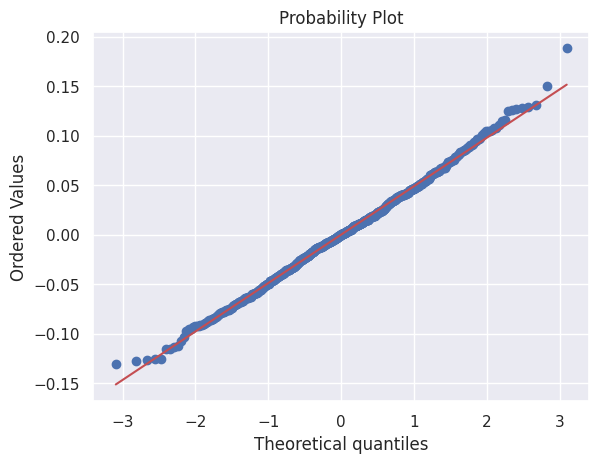

In [ ]:
import pylab
import scipy.stats as stats
plt.title("Fig 25: Q-Q plot of residuals")
stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
plt.show()

**Observations**

* The residuals almost follow a straight line except for the tails.
* Let's check the results of the Shapiro-Wilk test.

In [ ]:
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=np.float64(0.997315542716925), pvalue=np.float64(0.31085896470099983))

#### **Observations:**

**Observations**
* Since p-value < 0.05, the residuals are not normal as per the Shapiro-Wilk test.
* Strictly speaking, the residuals are not normal.
However, as an approximation, we can accept this distribution as close to being normal.
* **So, the assumption is satisfied.**

### **Test for Homoscedasticity**

TEST FOR HOMOSCEDASTICITY

* We will test for homoscedasticity by using the goldfeldquandt test.
* If we get a p-value greater than 0.05, we can say that the residuals are homoscedastic. Otherwise, they are heteroscedastic.

In [ ]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], X_train1)
lzip(name, test)

[('F statistic', np.float64(1.1313612904200752)),
 ('p-value', np.float64(0.12853551819087372))]

#### **Observations:**

**Observations**

* Since p-value > 0.05, the residuals are homoscedastic.
* **So, the assumption is satisfied.**

**All the assumptions of linear regression are satisfied. Let's rebuild our final model, check its performance, and draw inferences from it.**

## [**Predictions on test data**](https://)




Now that we have checked all the assumptions of linear regression and they are satisfied, let's go ahead with prediction.

In [ ]:
# predictions on the test set
pred  = olsmodel2.predict(X_test1)

df_pred_test = pd.DataFrame({"Actual": y_test, "Predicted": pred})
df_pred_test.sample(10, random_state=1)

,Actual,Predicted
983,0.43,0.434802
194,0.51,0.500314
314,0.48,0.430257
429,0.41,0.492544
267,0.41,0.487034
746,0.68,0.680000
186,0.62,0.595078
964,0.48,0.503909
676,0.42,0.490313
320,0.58,0.560155


* We can observe here that our model has returned pretty good prediction results, and the actual and predicted values are comparable

## [**Model Performance Evaluation**](https://)

#### **Final Model Summary**

In [ ]:
X_train_final = X_train1.copy()
X_test_final = X_test1.copy()

In [ ]:
olsmodel_final = sm.OLS(y_train, X_train_final).fit()
print(olsmodel_final.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     233.8
Date:                Wed, 09 Jul 2025   Prob (F-statistic):          7.03e-224
Time:                        05:53:44   Log-Likelihood:                 1120.2
No. Observations:                 700   AIC:                            -2216.
Df Residuals:                     688   BIC:                            -2162.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

#### **Testing the model performance on train and test data**

In [ ]:
# checking the model performance on train set
print('Train Performance')
olsmodel_train_pref = model_performance_regression_(olsmodel_final, X_train_final, y_train)
olsmodel_train_pref

Train Performance


,RMSE,MAE,MAPE,R2,Adj_R2
0,0.048841,0.038385,8.595246,0.788937,0.785251


In [ ]:
# testing the model performance on test data
print('Test Performance')
olsmodel_test_pref = model_performance_regression_(olsmodel_final, X_test_final, y_test)
olsmodel_test_pref

Test Performance


,RMSE,MAE,MAPE,R2,Adj_R2
0,0.051109,0.041299,9.177097,0.761753,0.751792


#### **Observations:**

**Observation:**

* We can see there is not much significant difference between Training and Test Data, so we can say our model is good.
* RMSE value not much changed of Training/Test result.
* MAE value also not having much differences in Training/Test result.
* R-Square just decreased in Testing as compare to training but this is marginal and can be accepted.
* Adj. R-Square also found decreased in test result but this change is also valid and acceptable.

## [**Actionable Insights & Recommendations**](https://)



* The model's R-squared value is approximately 0.788, and the adjusted R-squared is 0.785, indicating that the model can explain about 79% of the variance in the data. This is quite satisfactory.

* An increase of one unit in the 'visitors' variable results in a 0.1291 unit increase in content viewership, with all other variables held constant.

* Releasing content on Saturdays and Wednesdays will boost viewership, provided no major sports events occur on those days.

* Releasing content during the summer season can enhance viewership

* To improve content viewership, it is recommended to avoid releasing content on days when major sports events are happening.

* In Genre "Other" categories has the highest counts followed by the Comedy, Thriller, Drama etc.

* A major sports event will lead to a 0.0606 unit decrease in content viewership.

* The summer season can result in a 0.0434 unit increase in content viewership.